# Robust Angular Diameters in Python (`RADPy`) : SED Fitting Tutorial (Batch mode)

## Introduction to SED fitting

SED stands for Spectral Energy Distribution. For this purpose, SED fitting describes the process of taking photometry of a star and fitting a model stellar spectrum to that photometry. We use SED fits to determine stellar parameters such as temperature, surface gravity, metallicity, radii, and extinction. 

For interferometric analysis, you need a bolometric flux or $F_{Bol}$ in order to determine the limb darkened angular diameter. To get a bolometric flux, we use SED fits and then integrate under the curve, or model spectrum, over all wavelengths. `RADPy` is outfitted with its own SED fitting module. 

`RADPy` used the Python package `SEDFit` developed by Marina Kounkel (found [here:](https://github.com/mkounkel/SEDFit), with some adjustments made to the package which are incorporated into the SED fitting module. This package allows you to pick between four different stellar atmospheric models. A breakdown of the coverages between the four models can be seen in the table below:

| Model | Teff range  | logg range | Metallicity range |
|-------|-------------|------------|-------------------|
| Phoenix | $2300 \leq \rm T \leq 12000$ K | $0.0 \leq  \rm logg \leq +6.0$   | $-4.0 \leq \rm [Fe/H] \leq +1.0$|
| Kurucz  | $3750 \leq \rm T \leq 6000$ K  | $0.75 \leq  \rm logg \leq +5.25$ | $-3.0 \leq \rm [M/H] \leq +0.5$ |
| Coelho  | $3000 \leq \rm T \leq 25000$ K | $-0.5 \leq  \rm logg \leq +5.5$  | $0.0017 \leq \rm Z \leq 0.049$  |
| BT-SETTL| $400 \leq \rm T \leq 100000$ K | $-0.5 \leq  \rm logg \leq +5.5 $ | $-1.5 \leq \rm [M/H] \leq +0.5$ |

`SEDFit` contains all the model templates so no downloads are needed. This package performs a multi-component SED fitting routine. It enables a user to fit for some variety of the following parameters:

- Effective temperature, $\rm T_{eff}$
- Surface gravity, $\log{\rm g}$
- Metallicity, $\rm [Fe/H] $
- Distance, $\rm D$
- Extinction, $\rm A_{V}$
- Radius, $\rm R_{\star}$

Currently, `RADPy` allows users to fit for everything except for distance, as `RADPy` extracts a distance from a Gaia parallax. 

`RADPy` also has a photometry extraction function, which allows a user to pull photometry in common filters from Vizier catalogs. To extract photometry, `RADPy` makes use of the Python package, `astroARIADNE`, developed by Jose Vines (found [here:](https://github.com/jvines/astroARIADNE). This package has a very useful built-in photometry extraction function and `RADPy` only uses this package for this feature. 

`RADPy` also allows users to use their own input photometry file. Instructions on formatting are found down below in the rest of the tutorial notebook. 

## Installation instructions for `RADPY`'s SED fitting module

Both `SEDFit` and `astroARIADNE` contain dependencies that are unfortunately only compatible with Linux or MacOS systems. If you have either of these, skip the next sections and go down to the section titled "Setting up `SEDFit` and `astroARIADNE`. 

For anyone running Windows, I recommend setting up a WSL virtual environment that runs a Linux distribution. 

I have some general instructions below but please follow the WSL instructions on how to do so. 

### Setting up a virtual environment for Windows

I highly recommend getting Windows Subsystem for Linux (WSL). I use WSL with Ubuntu 24.04. If you do not have WSL, follow their download and set up instructions found [here:](https://ubuntu.com/desktop/wsl). 

I used miniforge in order to install python and conda within WSL. This link [here](https://kirenz.github.io/codelabs/codelabs/miniforge-setup/#0) has some helpful instructions on how to install miniforge if you are interested. Ensure you have a distribution of python that is at least verison 3.12. 

Once you have this in working order, we need to create a virtual environment.

To create your virtual environment, type 
```python
conda create -n [environment name]
```
It will default to the version of python that you currently have installed. 

To indicate which version, just add `python=[version num]` after `[environment name]`. 

Once you have the environment created, follow the install instructions for `RADPy`. This should ensure that all the packages needed for `RADPy` will be downloaded. 

## Setting up `SEDFit` and `astroARIADNE`

Because of these packages dependencies, these packages are not able to be added as a dependency of `RADPy`. To install, follow the instructions below:

### `SEDFit`

To install this package, use the following command:

```python
pip install git+https://github.com/mkounkel/SEDFit.git
```

After installation of `SEDFit`, there is one more step to set up the package. I have added additional filter profiles that `SEDFit` can use for photometry. However, this means you need to add these filter profiles to your install folder of `SEDFit`. 

The package folders are generally located in `path/to/python/distribution/lib/python#.##/site-packages`. 

For my WSL virtual environment, mine is located in `linux/Ubuntu-24.04/home/<user>/miniforge/envs/<name of env>/lib/python3.12/site-packages`.

The filter profiles are:

- GAIA.GAIA3.G
- GAIA.GAIA3.Gbp
- GAIA.GAIA3.Grp
- Hipparcos.Hipparcos.Hp_MvB
- Johnson.H
- Johnson.J
- Johnson.K
- Stromgren.b.dat
- Stromgren.u.dat
- Stromgren.v.dat
- Stromgren.y.dat
- TESS.TESS.Red.dat
- TYCHO.TYCHO.B_MvB
- TYCHO.TYCHO.V_MvB

These are needed if you have/want photometry in these bandpasses. If there is a bandpass that doesn't exist (See Step 1 for list of accepted bandpasses), please submit a request or contact me. 

The filter profiles are located on the Github repository in the directory: `radpy/data`. Download these and copy them into the `SEDFit` install file. 

And now you should be all set up with `SEDFit`.

### `astroARIADNE`

If you are interested in having `RADPy` pull photometry for your star for you, you need to install `astroARIADNE`.

To install this package:

```python
pip install astroariadne
```

If you are using `astroARIADNE` for photometry, the package will require dustmaps to be configured. This is already built in the the module and you will see the output of the configuration upon first run. It only needs to be configured once.

For both packages, some of the dependencies that are required for these packages aren't all up to date and/or aren't working properly. This is perfectly fine. You should be able to use the features of the SED fitter without an issue. 

If there is one, please submit an issue to `RADPy`'s Github repo. 

## What is in this notebook?

This tutorial is designed to show you how to use `RADPy`'s `sed_batch_mode()`. This is useful for those that have multiple stars they would like to fit at once or for those that don't want to go through the process step by step. 

## Usage

If you do use this package, please cite using the citation file located at <https://github.com/spaceashley/radpy> or use the below citation:


### **`RADPy`**
```
@software{Elliott_RADPy_Robust_Angular_2025,
    author = {Elliott, Ashley},
    doi = {10.5281/zenodo.17488122},
    license = {GPL-3.0-only},
    month = sep,
    title = {{RADPy: Robust Angular Diameters in Python}},
    url = {https://github.com/spaceashley/radpy},
    version = {0.10.0},
    year = {2025}
}
```
In addition, make sure you also cite:
### **`ARIADNE`**
```
@ARTICLE{2022MNRAS.tmp..920V,
       author = {{Vines}, Jose I. and {Jenkins}, James S.},
        title = "{ARIADNE: Measuring accurate and precise stellar parameters through SED fitting}",
      journal = {\mnras},
     keywords = {stars:atmospheres, methods:data analysis, stars:fundamental parameters, Astrophysics - Solar and Stellar Astrophysics, Astrophysics - Earth and Planetary Astrophysics, Astrophysics - Instrumentation and Methods for Astrophysics},
         year = 2022,
        month = apr,
          doi = {10.1093/mnras/stac956},
archivePrefix = {arXiv},
       eprint = {2204.03769},
 primaryClass = {astro-ph.SR},
       adsurl = {https://ui.adsabs.harvard.edu/abs/2022MNRAS.tmp..920V},
      adsnote = {Provided by the SAO/NASA Astrophysics Data System}
}
```
### **`SEDFit`**
```
@software{sedfit,
	author = {{Kounkel}, Marina},
	doi = {10.5281/zenodo.8076500},
	month = jun,
	publisher = {Zenodo},
	title = {SEDFit},
	url = {https://doi.org/10.5281/zenodo.8076500},
	year = 2023}
```
## Contact

- Ashley Elliott, (aelli76@lsu.edu)

## Resources
Link to the github repository: <https://github.com/spaceashley/radpy>

Link to the papers for each model:
- BT-Settl: <https://ui.adsabs.harvard.edu/abs/2011ASPC..448...91A/abstract> 

- Kurucz: <https://ui.adsabs.harvard.edu/abs/1992A%26A...264..557B/abstract>

- Coelho: <https://ui.adsabs.harvard.edu/abs/2014MNRAS.440.1027C/abstract> 

- PHOENIX: <https://ui.adsabs.harvard.edu/abs/2013A%26A...553A...6H/abstract>


## Step 1: Set-up your input file and your directories

To work batch mode for SED fitting, you need a few things: an input file and directories where all your photometry data will be. `RADPy` can extract your photometry if you need or you can give it your own photometry data files. 

### How to set up your data directory

If using your own photometry files, make sure that each data file contains the name of each star you would like to fit. The directory can be named whatever you like, just make note of it. 

### How to set up your input file

The input file requires several specific columns. This file will contain all the information `RADPy` needs to fit each SED for each star in your list. 

Your input file should contain the following information. The name of the columns and how the data should be inputted is described below. 

|Column name    | What is it?                   | Syntax         |
|---------------|-------------------------------|----------------|
| Star          | Name of your star             | `HD 158259`    |
| logg          | Surface gravity               | `4.0`          |
| dlogg         | Error on surface gravity      | `0.5`          |
| feh           | Metallicity                   | `0.0`          |
| dfeh          | Error on metallicity          | `0.5`          |
| fitteff       | Flag to fit temperature       | `True`         |
|               | Default is `False`            |                |
| fitteff_range | Range of temperatures to fit  | `[5000, 7000]` |
|               | Range should be [min, max]    |                |
| fitlogg       | Flag to fit surface gravity   | `False`        |
|               | Default is `False`            |                |
| fitlogg_range | Range of loggs to fit         | `[3.5, 5.0]`   |
|               | Range should be [min, max]    |                |
| fitfeh        | Flag to fit metallicity       | `False`        |
|               | Default is `False`            |                |
| fitfeh_range  | Range of metallicities to fit | `[-1.0, 1.0]`  |
|               | Range should be [min, max]    |                |
| fitav         | Flag to fit extinction        | `True`         |
|               | Default is `False`            |                |
| fitav_range   | Range of extinctions to fit   | `[0.0, 2.0]`   |
|               | Range should be [min, max]    |                |
| model         | Model selection for star      | `phoenix`      |
|               | Options are:                  |                |
|               | `phoenix`                     |                |
|               | `btsettl`                     |                |
|               | `coehlo`                      |                |
|               | `kurucz`                      |                |

There is a template file in 'radpy/data' entitled, 'template_starlist_batchmode.csv' which is available for you to download and input your target list information into. In this template, I have an example of what the file should look like when you input data into it. Just delete my examples, keep the columns, and input your own information. 


This file should be saved as a .csv file. 


Now you should be ready to go and run `sed_batchmode()`. 

## Step 2: Run `sed_batchmode()`

First step is to import the function: 

```python
from radpy.sed_batch_mode import *
```

The inputs for `sed_batchmode()` are described below:

| Parameter         | What is it?                                           | Syntax                     |
|------------------ |-------------------------------------------------------|----------------------------|
| `param_file`      | Path to your star input list file                     | `/path/to/file`            |
| `data_dir`        | Directory where your photometry files are             | `path/to/data/directory`   |
| `out_dir`         | Directory where you want the results to be            | `path/to/output/directory` |
| `res_out`         | Name of result file                                   | `ResultFile.txt`           |
| `diam_out`        | Name of result file for using diameter fit batch mode | `DiameterFile.txt`         |
| `unit`            | Unit you would like your fitting in                   | `'AA'`                     |
|                   | Options: Angstroms - `'AA'` or microns = `'micron'`   |                            |
| `set_axis`        | Allows you to set your own axis limits                | `set_axis = None`          |
|                   | I recommend leaving it as `None`                      |                            |
| `image_ext`       | Image extension you'd like to save your plots in      | `'.jpg'`                   |
|                   | Options include: .jpg, .png, .pdf, .eps               |                            |
| `uselatex`        | Flag to set plot font to Times New Roman              | `setlatex = False`         |
| `logplot`         | Flag to have the plots be in log format               | `logplot = True`           |
| `fbol_lam`        | Flag to have the flux multiplied by the wavelengths   | `fbol_lam = True`          |
| `own_photometry`  | Flag to tell the function to use photometry files     | `own_photometry = True`    |
|                   | already made or to extract them.                      |                            |
|                   | If `True`, will use your own files.                   |                            |
|                   | If `False`, will extract the photometry for you       |                            |
| `verbose`         | If `True`, will print results                         | `verbose = True`           |

After running `sed_batchmode()`, your SED fits will be saved in the file extension you chose in the directory you indicated. The results will be saved into two separate files: `res_out` and `diam_out`. `res_out` will contain the temperature determined by the SED fit, the extinction value determined by the SED fit, and the radius determined by the SED fit. `diam_out` will contain the bolometric flux value, the surface gravity, the metallicity, and the associated errors. `diam_out` will be in the correct format to input into the diameter fitting batch mode that `RADPy` has. 

If you chose to let `RADPy` extract photometry for you, I highly recommend inspecting the photometry it pulled, especially if the SED fits look odd. If you find that something isn't correct in the photometry file, remove or add photometry values to the files following the same filter name as the template in the single mode tutorial. Save the file and re-run `sed_batchmode()` and set the `own_photometry` flag to `True`. 

/home/oxfor/miniforge/envs/test_env/lib/python3.12/site-packages/radpy/sedfit.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Holoviews not imported. Some visualizations will not be available.
PyMultiNest not imported.  MultiNest fits will not work.
/home/oxfor/miniforge/envs/test_env/lib/python3.12/site-packages/astroARIADNE/fitter.py:43: UserWarning: (py)MultiNest installation (or libmultinest.dylib) not detected.
  warnings.warn(


Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
--------------------------------------------------
Starting processing for HD 1461
Finding user generated photometry files
Files found for HD 1461: ['/mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry/HD1461mags.dat']

Coordinates in decimal degrees for HD 1461:
RA: 4.674448649133749, Dec: -8.053001063860556

Coordinates in sexagesimal format for HD 1461:
RA: 0:18:41.86768, Dec: -8:03:10.80383
Found Gaia DR3 ID: Gaia DR3 2430102808294101760
Found Gaia DR3 ID: Gaia DR3 2430102808294101760
Corrected parallax: 42.6953 [mas]
Distance: 23.42178 +/- 0.01638 [pc]
Chi squared: 327.741896286907
Chi squared reduced: 18.207883127050387
Distance: 23.42178 pc
AV: 0 mag
Radius: [np.float64(1.2608039632949726)] Rsun
Teff: [np.float64(5337.997902289952)] K
Log g: [4.35] 
Fe/H: 0.19
Fbol =  6.65134 +/- 0.29451 x10^(-8) erg/s/cm^

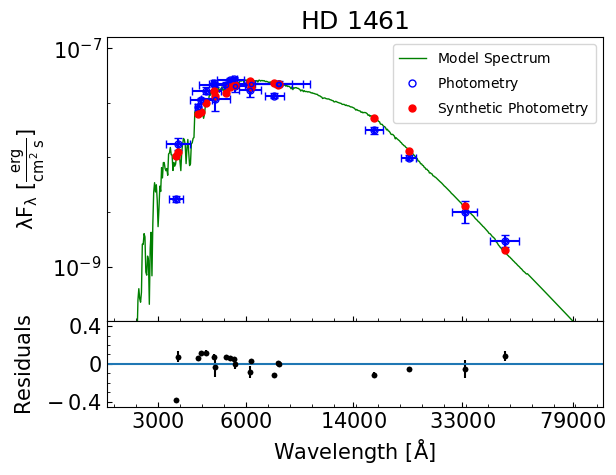

Finished processing HD 1461
--------------------------------------------------
Starting processing for HD 164922
Finding user generated photometry files
Files found for HD 164922: ['/mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry/HD164922mags.dat']

Coordinates in decimal degrees for HD 164922:
RA: 270.6285930918625, Dec: 26.31300139555889

Coordinates in sexagesimal format for HD 164922:
RA: 18:02:30.86234, Dec: 26:18:46.80502
Found Gaia DR3 ID: Gaia DR3 4582680493669880704
Found Gaia DR3 ID: Gaia DR3 4582680493669880704
Corrected parallax: 45.46795 [mas]
Distance: 21.99351 +/- 0.00806 [pc]
Chi squared: 335.7202674518643
Chi squared reduced: 22.38135116345762
Distance: 21.99351 pc
AV: 0 mag
Radius: [np.float64(1.0295347388986908)] Rsun
Teff: [np.float64(5511.774298570962)] K
Log g: [np.float64(4.499999837585331)] 
Fe/H: 0.18
Fbol =  4.41919 +/- 0.77536 x10^(-8) erg/s/cm^s/angstrom


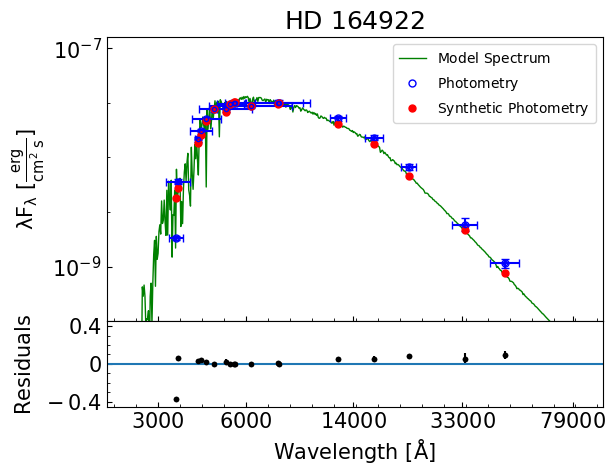

Finished processing HD 164922
--------------------------------------------------
Starting processing for HD 127334
Finding user generated photometry files
Files found for HD 127334: ['/mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry/HD127334mags.dat']

Coordinates in decimal degrees for HD 127334:
RA: 217.40336988418, Dec: 41.79591262141

Coordinates in sexagesimal format for HD 127334:
RA: 14:29:36.80877, Dec: 41:47:45.28544
Found Gaia DR3 ID: Gaia DR3 1491593733326694912
Found Gaia DR3 ID: Gaia DR3 1491593733326694912
Corrected parallax: 42.72463 [mas]
Distance: 23.40571 +/- 0.00952 [pc]
Chi squared: 326.53323151005293
Chi squared reduced: 20.408326969378308
Distance: 23.40571 pc
AV: 0 mag
Radius: [np.float64(1.3376704412634206)] Rsun
Teff: [np.float64(5352.3835305007)] K
Log g: [4.27] 
Fe/H: 0.18
Fbol =  7.58006 +/- 0.33128 x10^(-8) erg/s/cm^s/angstrom


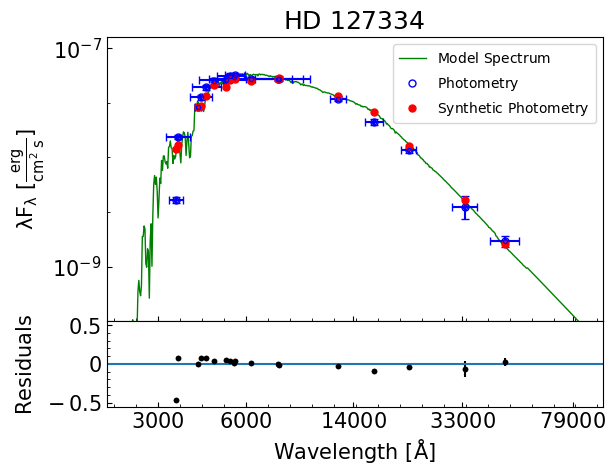

Finished processing HD 127334
Batch complete. Fit 3 stars. Plots in /mnt/c/Users/oxfor/Research/rsadpy//tests/test_data/photometry/plots, SED fit results in SEDresults.txt, File for diameter fitting in stardatafordiams.txt


In [1]:
from radpy.sed_batch_mode import *
data_dir = "/mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry"
param_file = '/mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry/allphot_test.csv'
out_dir = "/mnt/c/Users/oxfor/Research/rsadpy//tests/test_data/photometry"
res_out = "SEDresults.txt"
diam_out = "stardatafordiams.txt"
unit = 'AA'
set_axis = None
image_ext = '.jpg'
uselatex = False
logplot = True
fbol_lam = True
own_photometry = True
sed_batchmode(param_file, data_dir, out_dir, res_out, diam_out, unit, set_axis, image_ext, uselatex,
              logplot, fbol_lam, own_photometry, verbose = True)